Linear Regression Model Training

In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [68]:
df=pd.read_csv("C:\\Users\\manis\\Downloads\\Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [69]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [70]:
for col in df.select_dtypes(include='object').columns:
    print(col)

mainroad
guestroom
basement
hotwaterheating
airconditioning
prefarea
furnishingstatus


In [71]:
binary_col=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_col:
    if col in df.columns:
        df[col]=df[col].map({'yes':1,"no":0})
        

In [72]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [73]:
df=pd.get_dummies(df,columns=['furnishingstatus'],dtype=int)

In [74]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1,0,0


In [75]:
corr=df.corr()["price"].sort_values(ascending=False)
corr

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
furnishingstatus_furnished         0.229350
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

In [76]:
df=df.drop(columns=['basement','hotwaterheating','furnishingstatus_semi-furnished'])
df          

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,1,2,1,1,0
1,12250000,8960,4,4,4,1,0,1,3,0,1,0
2,12250000,9960,3,2,2,1,0,0,2,1,0,0
3,12215000,7500,4,2,2,1,0,1,3,1,1,0
4,11410000,7420,4,1,2,1,1,1,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,1,0


In [77]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,1,2,1,1,0
1,12250000,8960,4,4,4,1,0,1,3,0,1,0
2,12250000,9960,3,2,2,1,0,0,2,1,0,0
3,12215000,7500,4,2,2,1,0,1,3,1,1,0
4,11410000,7420,4,1,2,1,1,1,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,1,0


In [78]:
X=df.drop(columns=['price'])
Y=df["price"]

In [79]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,1,2,1,1,0
1,8960,4,4,4,1,0,1,3,0,1,0
2,9960,3,2,2,1,0,0,2,1,0,0
3,7500,4,2,2,1,0,1,3,1,1,0
4,7420,4,1,2,1,1,1,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,0,2,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0
542,3620,2,1,1,1,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,1,0


In [80]:
Y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [81]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [82]:
model=LinearRegression()
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [83]:
#to make prediction on the testing set
Y_Pred=model.predict(X_test)
Y_Pred

array([4929662.22333508, 7359204.64313159, 3260127.78740157,
       4708688.6193149 , 3498860.75278122, 3646432.77499631,
       5781825.40260579, 6418091.5295392 , 3018139.96977365,
       2842454.1635831 , 9765338.53119368, 2900967.98579507,
       3253096.54172481, 3135950.76786245, 3368700.25807455,
       5611991.43621709, 3143638.51392861, 4838899.41303538,
       4033848.6990767 , 3705249.98058418, 5748700.85224129,
       5860149.0889829 , 2836243.58525576, 4652085.59706251,
       5043570.97794711, 7359438.3325885 , 3116136.60306953,
       5176446.16411391, 7868424.05431628, 3514887.50584372,
       6300499.73904331, 3413857.07285807, 6975542.05595827,
       4304474.98238036, 3664273.68773766, 5998001.44410353,
       4740541.54609942, 4073029.38786794, 3311347.16941046,
       4833984.89297909, 4744058.6242021 , 3602913.86521043,
       7341036.39034863, 4138361.18422523, 3875577.35042446,
       4353225.99113272, 6771353.71218808, 4206896.128438  ,
       3835724.59147854,

In [84]:
# . Evaluate the Model Performance
mae = mean_absolute_error(Y_test, Y_Pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_Pred))
r2 = r2_score(Y_test, Y_Pred)

In [85]:
print(mae)
print(rmse)
print(r2)

976657.1631882217
1347956.2376715608
0.6405261119901835


**Training a second Model(Random Forest Regressor)**

In [86]:
from sklearn.ensemble import RandomForestRegressor

In [87]:
x=df.drop(columns=['price'])
y=df['price']

In [88]:
x

,area,bedrooms,bathrooms,stories,mainroad,guestroom,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,1,2,1,1,0
1,8960,4,4,4,1,0,1,3,0,1,0
2,9960,3,2,2,1,0,0,2,1,0,0
3,7500,4,2,2,1,0,1,3,1,1,0
4,7420,4,1,2,1,1,1,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,0,2,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0
542,3620,2,1,1,1,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,1,0


In [89]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [90]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [91]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
y_pred_rf=rf_model.predict(x_test)
y_pred_rf

array([5199600.        , 7429660.        , 3974967.5       ,
       4677820.        , 4073790.        , 3522610.        ,
       5084940.        , 5328470.        , 2655800.        ,
       2939559.        , 9935409.4       , 3358921.66666667,
       2977846.66666667, 3195570.        , 3041885.        ,
       4057270.        , 3333736.        , 5095720.        ,
       3386880.        , 3981775.        , 5497310.        ,
       5917450.        , 3052116.66666667, 3592820.        ,
       4204760.        , 6967100.        , 2937200.        ,
       4708550.        , 6030990.        , 3323250.        ,
       5641580.        , 3071180.        , 6966190.        ,
       4424070.        , 3104570.        , 6357750.        ,
       5112030.        , 3315025.        , 3140760.        ,
       4424630.        , 4077430.        , 2824675.        ,
       7578830.        , 4958380.        , 4081070.        ,
       4412625.        , 7189169.4       , 4121915.        ,
       3041220.        ,

In [93]:
mae_rf=mean_absolute_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf=r2_score(y_test,y_pred_rf)

In [94]:
print(f"Mean Absolute error is:{mae_rf}")
print(f"Root Mean Absolute error is:{rmse_rf}")
print(f"R2 score is:{r2_rf}")

Mean Absolute error is:1028424.8828746177
Root Mean Absolute error is:1406993.569649513
R2 score is:0.6083483246749224


**Comparison Table**

In [95]:
comparison_data = {
    'Metric': ['MAE', 'RMSE',"R2-Score"],
    'Linear Regression': [f"{mae:,.4f}", f"{rmse:,.2f}", f"{r2:,.2f}"],
    'Random Forest': [f"{mae_rf:.4f}", f"{rmse_rf:,.2f}", f"{r2_rf:,.2f}"],
    'Winner': ['Linear Regression', 'Linear Regression', 'Linear Regression']
}
comparision=pd.DataFrame(comparison_data)
comparision


,Metric,Linear Regression,Random Forest,Winner
0,MAE,"976,657.1632",1028424.8829,Linear Regression
1,RMSE,"1,347,956.24","1,406,993.57",Linear Regression
2,R2-Score,0.64,0.61,Linear Regression




**Diagram **

**Diagram**


In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

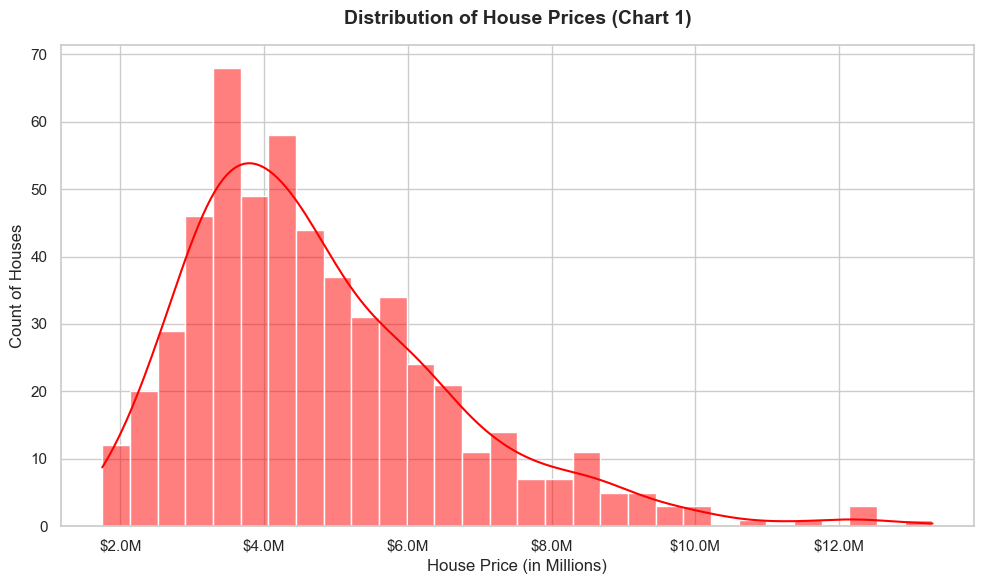

In [98]:
# CHART 1: Histogram - Distribution of House Prices
plt.figure()
sns.histplot(df['price'], kde=True, color='red', bins=30)
# Format the X-axis tags clearly into Millions ($M)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))

plt.title('Distribution of House Prices (Chart 1)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('House Price (in Millions)', fontsize=12)
plt.ylabel('Count of Houses', fontsize=12)
plt.tight_layout()
plt.show()

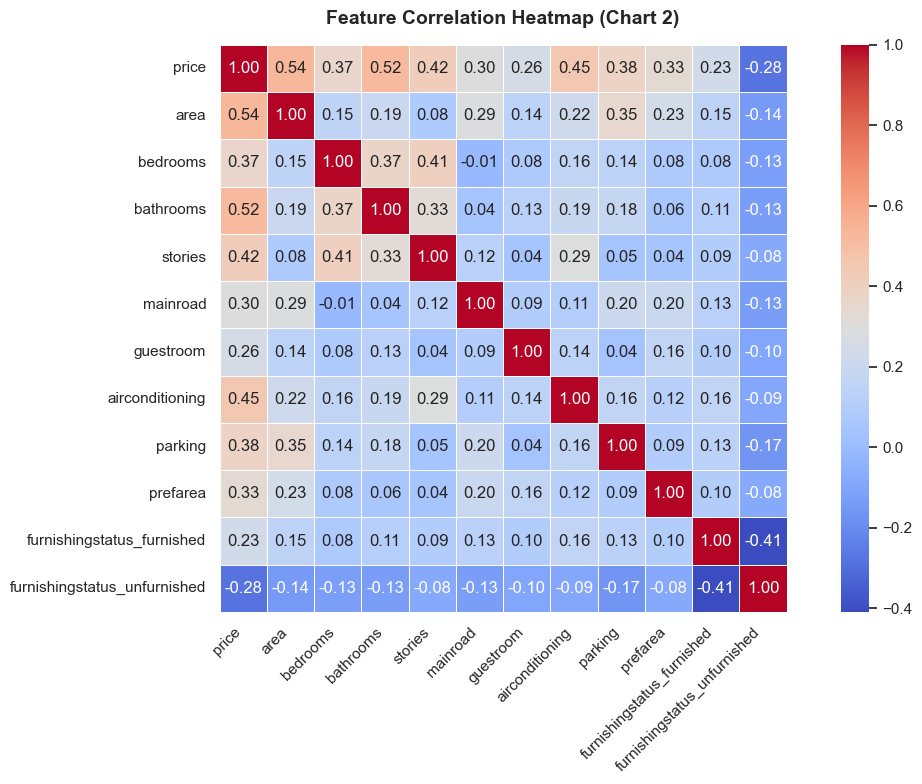

In [99]:
# CHART 2: Correlation Heatmap
plt.figure(figsize=(12, 8))

# Calculate correlations on the clean numeric dataframe matrix
corr_matrix = df.corr()

# Draw the matrix map (coolwarm shows negative as blue, positive as red)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, cbar=True, square=True)

plt.title('Feature Correlation Heatmap (Chart 2)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


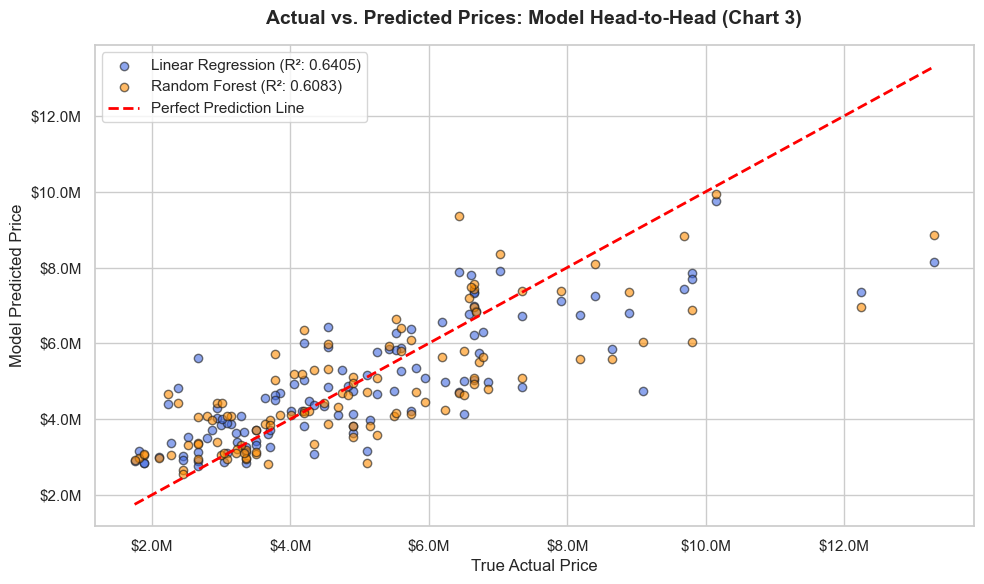

In [100]:

# CHART 3: Actual vs. Predicted Price Comparison (Creative Choice)
plt.figure()

# Plot Linear Regression (Blue Dots)
plt.scatter(Y_test, Y_Pred, color='royalblue', alpha=0.6, 
            label=f'Linear Regression (R²: 0.6405)', edgecolors='k')

# Plot Random Forest (Orange Dots)
plt.scatter(y_test, y_pred_rf, color='darkorange', alpha=0.6, 
            label=f'Random Forest (R²: 0.6083)', edgecolors='k')

# Add the 45-degree reference line (The closer the dots are here, the better!)
max_val = max(max(y_test), max(Y_Pred), max(y_pred_rf))
min_val = min(min(y_test), min(Y_Pred), min(y_pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

# Format both axis labels cleanly into Millions ($M)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))

plt.title('Actual vs. Predicted Prices: Model Head-to-Head (Chart 3)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('True Actual Price', fontsize=12)
plt.ylabel('Model Predicted Price', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()


**Insights & Summary**

In [101]:
""" Question 1.Which features influence house price the most?
Ans:Area, bathrooms, airconditioning and stories features influence the house price the most

Question 2.
 How accurate was your model (in plain terms)?
 Ans: The model accuracy using linear regression model is 64% which means it can explain 64% variations in the data but not perfect 
 due to fluctuations of the house price from neighbour to neighbour.

 Question 3. What surprised you in the data?
 Ans:In this dataset the price of the some houses is very high (mansion type) which is acting as a outlier and fluctutation of the
 price from neighbour to neighbour .so, the linear model or random forest model is not very accurate for this dataset.

 Question 4. One recommendation for a real estate business based on your findings
Ans:The one recommendation is to prioritize the installation or the upgrading  air conditioning in medium to large properties before 
    listing them.
"""

' Question 1.Which features influence house price the most?\nAns:Area, bathrooms, airconditioning and stories features influence the house price the most\n\nQuestion 2.\n How accurate was your model (in plain terms)?\n Ans: The model accuracy using linear regression model is 64% which means it can explain 64% variations in the data but not perfect \n due to fluctuations of the house price from neighbour to neighbour.\n\n Question 3. What surprised you in the data?\n Ans:In this dataset the price of the some houses is very high (mansion type) which is acting as a outlier and fluctutation of the\n price from neighbour to neighbour .so, the linear model or random forest model is not very accurate for this dataset.\n\n Question 4. One recommendation for a real estate business based on your findings\nAns:The one recommendation is to prioritize the installation or the upgrading  air conditioning in medium to large properties before \n    listing them.\n'